# Flop Club — анализ турнирной статистики



In [82]:
import pandas as pd
import matplotlib.pyplot as plt


In [83]:

tournaments = pd.read_csv('./data/tournaments.csv')
tournaments["starts_at"] = pd.to_datetime(tournaments["starts_at"])
tournaments["late_registration_ends_at"] = pd.to_datetime(tournaments["late_registration_ends_at"])
tournaments["created_date"] = pd.to_datetime(tournaments["created_date"])
tournaments["add_on_enabled"] = tournaments["add_on_enabled"].map({"t": True, "f": False})
tournaments["allow_cancellation"] = tournaments["allow_cancellation"].map({"t": True, "f": False})
tournaments["profile"] = tournaments["profile"].astype("category")
tournaments["status"] = tournaments["status"].astype("category")
tournaments.info()
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         54 non-null     object        
 1   title                      54 non-null     object        
 2   description                54 non-null     object        
 3   starts_at                  54 non-null     datetime64[ns]
 4   location                   54 non-null     object        
 5   buy_in                     54 non-null     int64         
 6   re_entry                   54 non-null     int64         
 7   prize_pool                 54 non-null     int64         
 8   rating_pool                54 non-null     int64         
 9   rating_series_month        17 non-null     object        
 10  entries_count              45 non-null     float64       
 11  profile                    54 non-null     category      
 12  late_regis

In [84]:
registrations = pd.read_csv( "./data/registrations.csv")

registrations["created_date"] = pd.to_datetime(registrations["created_date"])
registrations["checked_in"] = registrations["checked_in"].map({"t": True, "f": False})
registrations["status"] = registrations["status"].astype("category")
registrations["live_status"] = registrations["live_status"].astype("category")
registrations["finish_place"] = registrations["finish_place"].astype("Int64")

registrations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   registration_id  835 non-null    object        
 1   player_id        835 non-null    object        
 2   tournament_id    835 non-null    object        
 3   status           835 non-null    category      
 4   live_status      835 non-null    category      
 5   finish_place     701 non-null    Int64         
 6   entry_number     835 non-null    int64         
 7   add_on_count     835 non-null    int64         
 8   checked_in       835 non-null    bool          
 9   created_date     835 non-null    datetime64[ns]
dtypes: Int64(1), bool(1), category(2), datetime64[ns](1), int64(2), object(3)
memory usage: 49.3+ KB


## 0. Data quality — проверь это до расчёта метрик

In [85]:

pct_missing_place = registrations["finish_place"].isna().mean() * 100
print(f"Регистраций без finish_place: {pct_missing_place:.1f}%")


last_day = tournaments["starts_at"].max()
print(f"Последняя дата турнира в данных: {last_day.date()} — "
      f"если это середина месяца, последний месяц в графиках ниже НЕПОЛНЫЙ.")

Регистраций без finish_place: 16.0%
Последняя дата турнира в данных: 2026-09-13 — если это середина месяца, последний месяц в графиках ниже НЕПОЛНЫЙ.


## 1. Рост и посещаемость\nВопрос: растут ли число турниров и посадка от месяца к месяцу?

In [86]:
active = registrations[registrations["status"] == "ACTIVE"]
entries_per_t = active.groupby("tournament_id").size().rename("active_entries")
 
tt = tournaments.merge(entries_per_t, left_on="id", right_index=True, how="left")

tt = tt[tt["status"] == "FINISHED"].copy()  # исключаем ещё не сыгранные OPEN-турниры
tt["active_entries"] = tt["active_entries"].fillna(0)
tt["month"] = tt["starts_at"].dt.to_period("M")
 
monthly = tt.groupby("month").agg(
        tournaments=("id", "count"),
        avg_entries=("active_entries", "mean"),
        total_entries=("active_entries", "sum"),
    ).reset_index()
monthly["month"] = monthly["month"].astype(str)

print("=" * 70)
print("БЛОК 1: РОСТ И ПОСЕЩАЕМОСТЬ")
print("=" * 70)
print(monthly.to_string(index=False))
print("Считаем только по FINISHED турнирам — OPEN (ещё не сыгранные) турниры "
          "исключены, иначе они искусственно занижают среднюю посадку последнего месяца.\n")

БЛОК 1: РОСТ И ПОСЕЩАЕМОСТЬ
  month  tournaments  avg_entries  total_entries
2026-06           15    14.933333          224.0
2026-07           14    16.785714          235.0
2026-08           14    14.642857          205.0
2026-09            3    21.000000           63.0
Считаем только по FINISHED турнирам — OPEN (ещё не сыгранные) турниры исключены, иначе они искусственно занижают среднюю посадку последнего месяца.



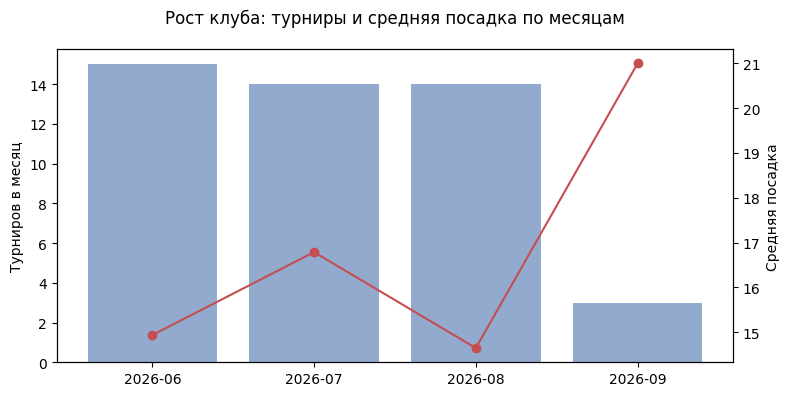

In [69]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(monthly["month"], monthly["tournaments"], color="#4C72B0", alpha=0.6, label="Турниров")
ax1.set_ylabel("Турниров в месяц")
ax2 = ax1.twinx()
ax2.plot(monthly["month"], monthly["avg_entries"], color="#C44E52", marker="o", label="Средняя посадка")
ax2.set_ylabel("Средняя посадка")
fig.suptitle("Рост клуба: турниры и средняя посадка по месяцам")
fig.tight_layout()
plt.show()
plt.close(fig)

In [70]:
playars = pd.read_csv( "./data/players.csv")

## 2. Удержание / отток\nВопрос: какая доля игроков возвращается после первого турнира?

In [71]:
total = len(playars)
zero_played = (playars["tournaments_played"] == 0).sum()
played_once = (playars["tournaments_played"] == 1).sum()
 
print("=" * 70)
print("БЛОК 2: УДЕРЖАНИЕ / ОТТОК")
print("=" * 70)
print(f"Всего игроков: {total}")
print(f"Зарегистрировались, но не сыграли ни разу: {zero_played} ({zero_played/total:.1%})")
print(f"Сыграли ровно 1 турнир: {played_once} ({played_once/total:.1%})")
 
p_sorted = playars.sort_values("tournaments_played", ascending=False).reset_index(drop=True)
total_entries = p_sorted["tournaments_played"].sum()
top10_share = p_sorted.head(max(1, total // 10))["tournaments_played"].sum() / total_entries
print(f"Топ-10% игроков дают {top10_share:.1%} всех посещений (Парето-концентрация)\n")

БЛОК 2: УДЕРЖАНИЕ / ОТТОК
Всего игроков: 191
Зарегистрировались, но не сыграли ни разу: 17 (8.9%)
Сыграли ровно 1 турнир: 76 (39.8%)
Топ-10% игроков дают 46.3% всех посещений (Парето-концентрация)



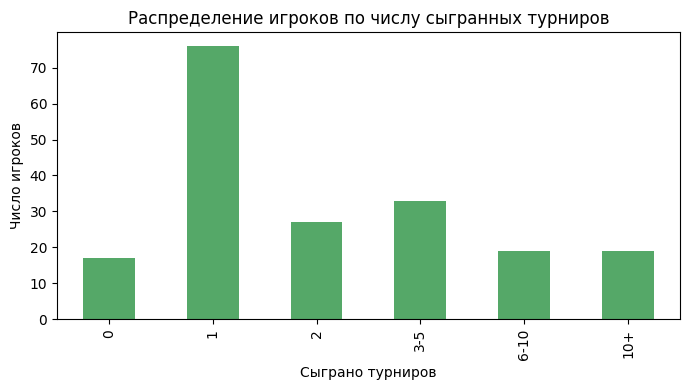

In [72]:
buckets = pd.cut(
        playars["tournaments_played"],
        bins=[-1, 0, 1, 2, 5, 10, playars["tournaments_played"].max()],
        labels=["0", "1", "2", "3-5", "6-10", "10+"],
    )
dist = buckets.value_counts().sort_index()
 
fig, ax = plt.subplots(figsize=(7, 4))
dist.plot(kind="bar", ax=ax, color="#55A868")
ax.set_xlabel("Сыграно турниров")
ax.set_ylabel("Число игроков")
ax.set_title("Распределение игроков по числу сыгранных турниров")
fig.tight_layout()
plt.show()



### Когортное удержание
### Какая доля игроков когорты (месяц первой игры) вернулась через 1/2/3 месяца?

In [73]:
active = registrations[registrations["status"] == "ACTIVE"].merge(
        tournaments[["id", "starts_at"]], left_on="tournament_id", right_on="id", how="left"
    )
active["month"] = active["starts_at"].dt.to_period("M")
 
first_month = active.groupby("player_id")["month"].min().rename("cohort_month")
act2 = active.merge(first_month, on="player_id")
act2["month_offset"] = act2["month"].astype(int) - act2["cohort_month"].astype(int)
 
cohort_sizes = first_month.value_counts().sort_index()
pivot = act2.groupby(["cohort_month", "month_offset"])["player_id"].nunique().unstack(fill_value=0)
retention_pct = pivot.divide(cohort_sizes, axis=0) * 100
 
last_month = active["month"].max()
mask = pd.DataFrame(index=retention_pct.index, columns=retention_pct.columns, dtype=bool)
for cm in retention_pct.index:
    for off in retention_pct.columns:
        mask.loc[cm, off] = (cm + off) <= last_month
    retention_masked = retention_pct.where(mask)
 
print("=" * 70)
print("КОГОРТНОЕ УДЕРЖАНИЕ (% игроков когорты, вернувшихся через N месяцев)")
print("=" * 70)
print("Размер когорт (новых игроков по месяцу первой игры):")
print(cohort_sizes.to_string())

print(retention_masked.round(1).to_string())
print(f"NaN = месяц ещё не наступил (censored). Последний месяц в данных ({last_month}) "
          f"неполный — трактовать offset для него с осторожностью.\n")

КОГОРТНОЕ УДЕРЖАНИЕ (% игроков когорты, вернувшихся через N месяцев)
Размер когорт (новых игроков по месяцу первой игры):
cohort_month
2026-06    96
2026-07    41
2026-08    28
2026-09     9
Freq: M
month_offset      0     1     2     3
cohort_month                         
2026-06       100.0  44.8  29.2  17.7
2026-07       100.0  53.7  29.3   NaN
2026-08       100.0  21.4   NaN   NaN
2026-09       100.0   NaN   NaN   NaN
NaN = месяц ещё не наступил (censored). Последний месяц в данных (2026-09) неполный — трактовать offset для него с осторожностью.



C:\Users\Andre\AppData\Local\Temp\ipykernel_11164\161355537.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


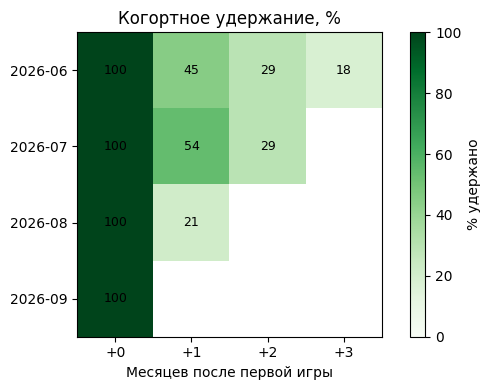

In [74]:
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(retention_masked.values.astype(float), cmap="Greens", vmin=0, vmax=100)
ax.set_xticks(range(len(retention_masked.columns)))
ax.set_xticklabels([f"+{c}" for c in retention_masked.columns])
ax.set_yticks(range(len(retention_masked.index)))
ax.set_yticklabels([str(i) for i in retention_masked.index])
ax.set_xlabel("Месяцев после первой игры")
ax.set_title("Когортное удержание, %")
for i in range(retention_masked.shape[0]):
    for j in range(retention_masked.shape[1]):
        v = retention_masked.values[i, j]
        if not pd.isna(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, label="% удержано")
fig.tight_layout()
fig.show()

## 3. Юнит-экономика турниров
## Вопрос: окупают ли сборы с игроков объявленные гарантии призовых?

In [75]:
finished_ids = set(tournaments.loc[tournaments["status"] == "FINISHED", "id"])
 
active = registrations[(registrations["status"] == "ACTIVE") & (registrations["tournament_id"].isin(finished_ids))].merge(
        tournaments[["id", "buy_in", "re_entry", "add_on_price"]],
        left_on="tournament_id", right_on="id", how="left",
    )
active["unit_cost"] = active["buy_in"].where(active["entry_number"] == 1, active["re_entry"])
active["total_cost"] = active["unit_cost"] + active["add_on_count"] * active["add_on_price"]
 
collected = active.groupby("tournament_id")["total_cost"].sum().rename("gross_collected_rub")
 
finished = tournaments[tournaments["status"] == "FINISHED"].copy().set_index("id")
finished["gross_collected_rub"] = collected.reindex(finished.index).fillna(0)
 
print("=" * 70)
print("БЛОК 3: РЕАЛЬНАЯ ВЫРУЧКА (только buy_in/re_entry/add_on, в рублях)")
print("=" * 70)
print(f"Собрано с игроков за весь период: {finished['gross_collected_rub'].sum():,.0f} ₽")
print("prize_pool в эту сумму намеренно не входит — это очки рейтинга, не деньги.\n")
 
by_month = finished.copy()
by_month["month"] = pd.to_datetime(by_month["starts_at"]).dt.to_period("M").astype(str)
monthly_revenue = by_month.groupby("month")["gross_collected_rub"].sum()

БЛОК 3: РЕАЛЬНАЯ ВЫРУЧКА (только buy_in/re_entry/add_on, в рублях)
Собрано с игроков за весь период: 396,000 ₽
prize_pool в эту сумму намеренно не входит — это очки рейтинга, не деньги.



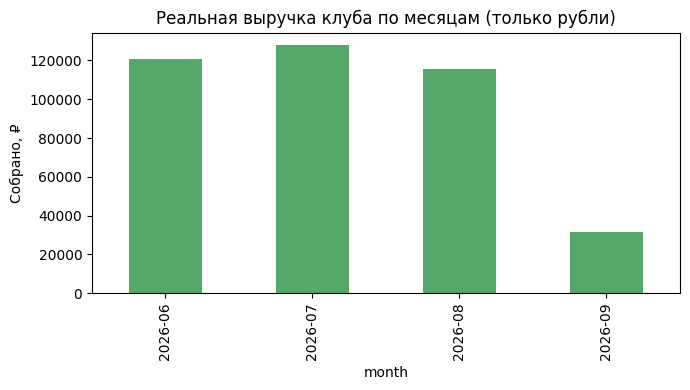

In [76]:
fig, ax = plt.subplots(figsize=(7, 4))
monthly_revenue.plot(kind="bar", ax=ax, color="#55A868")
ax.set_ylabel("Собрано, ₽")
ax.set_title("Реальная выручка клуба по месяцам (только рубли)")
fig.tight_layout()
plt.show()


### LTV-прокси (revenue to date)

Это НЕ прогнозный LTV — это накопленная выручка на игрока на сегодня
(бай-ины + ре-энтри + аддоны по всем его регистрациям, включая ещё не
сыгранные предоплаченные турниры). Выигрыши не вычитаются: в
`rating_results` нет надёжного денежного поля (`percent`/`points`
относятся к отдельному рейтинговому пулу очков, не обязательно к
деньгам) — уточни это у клуба перед тем, как называть цифру "чистым" LTV.

In [77]:
active = registrations[registrations["status"] == "ACTIVE"].merge(
        tournaments[["id", "starts_at", "buy_in", "re_entry", "add_on_price"]],
        left_on="tournament_id", right_on="id", how="left",
    )
active["unit_cost"] = active["buy_in"].where(active["entry_number"] == 1, active["re_entry"])
active["total_cost"] = active["unit_cost"] + active["add_on_count"] * active["add_on_price"]
 
ltv = active.groupby("player_id")["total_cost"].sum().rename("revenue_to_date_rub")
 
active["month"] = active["starts_at"].dt.to_period("M")
first_month = active.groupby("player_id")["month"].min().rename("cohort_month")
by_cohort = ltv.to_frame().join(first_month).groupby("cohort_month")["revenue_to_date_rub"].mean()
 
print("=" * 70)
print("LTV-ПРОКСИ (REVENUE TO DATE, В РУБЛЯХ) — не прогнозный LTV, а факт на сегодня")
print("=" * 70)
print(f"ARPU (среднее на игравшего игрока): {ltv.mean():,.0f} ₽")
print(f"Медиана: {ltv.median():,.0f} ₽  |  Максимум: {ltv.max():,.0f} ₽")
print("\nСредняя revenue-to-date по когорте месяца первой игры:")
print(by_cohort.round(0).to_string())
print("Более новые когорты просто не успели накопить столько же — "
          "это эффект возраста когорты, а не падающая ценность новых игроков.\n")
 

LTV-ПРОКСИ (REVENUE TO DATE, В РУБЛЯХ) — не прогнозный LTV, а факт на сегодня
ARPU (среднее на игравшего игрока): 2,302 ₽
Медиана: 1,000 ₽  |  Максимум: 19,000 ₽

Средняя revenue-to-date по когорте месяца первой игры:
cohort_month
2026-06    2724.0
2026-07    2415.0
2026-08    1268.0
2026-09     500.0
Freq: M
Более новые когорты просто не успели накопить столько же — это эффект возраста когорты, а не падающая ценность новых игроков.



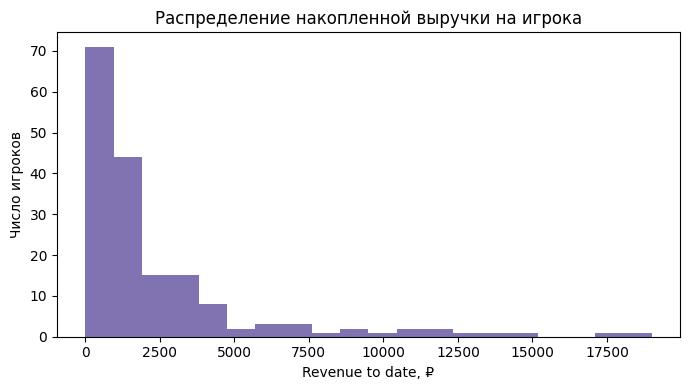

In [78]:
fig, ax = plt.subplots(figsize=(7, 4))
ltv.plot(kind="hist", bins=20, ax=ax, color="#8172B2")
ax.set_xlabel("Revenue to date, ₽")
ax.set_ylabel("Число игроков")
ax.set_title("Распределение накопленной выручки на игрока")
fig.tight_layout()

plt.show()

## 4. Форматы турниров
## Вопрос: какие форматы дают лучшую посадку?

In [79]:
active = registrations[registrations["status"] == "ACTIVE"]
entries = active.groupby("tournament_id").size().rename("entries")
tt = tournaments.merge(entries, left_on="id", right_index=True, how="left")
tt = tt[tt["status"] == "FINISHED"]
 
by_profile = tt.groupby("profile", observed=True).agg(
        tournaments=("id", "count"),
        avg_entries=("entries", "mean"),
        avg_buy_in=("buy_in", "mean"),
    ).sort_values("avg_entries", ascending=False)
 
corr = tt["buy_in"].corr(tt["entries"])
 
print("=" * 70)
print("БЛОК 4: ФОРМАТЫ ТУРНИРОВ")
print("=" * 70)
print(by_profile.round(1).to_string())
print(f"\nКорреляция бай-ина и посадки: {corr:.2f} "
          f"({'дороже вход — меньше людей' if corr < 0 else 'связи почти нет'})")
print("Осторожно: бай-ин перепутан с форматом (confounding) — нельзя разделить "
          "эффект цены и эффект формата без контролируемого теста.\n")

БЛОК 4: ФОРМАТЫ ТУРНИРОВ
              tournaments  avg_entries  avg_buy_in
profile                                           
PHOENIX                 2         29.0       250.0
KNOCKOUT                9         20.2       555.6
TURBO_ACTION            3         17.7       500.0
DEEP_SPECIAL           10         14.4       500.0
BASE                   13         13.6       500.0
FINAL                   3         12.7       500.0
FREEZE                  6         12.5       833.3

Корреляция бай-ина и посадки: -0.47 (дороже вход — меньше людей)
Осторожно: бай-ин перепутан с форматом (confounding) — нельзя разделить эффект цены и эффект формата без контролируемого теста.



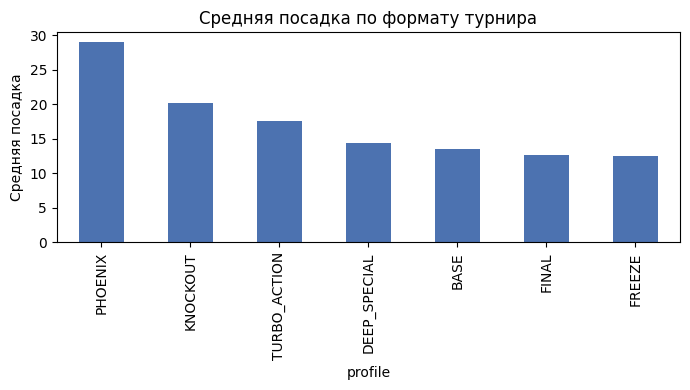

In [80]:
fig, ax = plt.subplots(figsize=(7, 4))
by_profile["avg_entries"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Средняя посадка")
ax.set_title("Средняя посадка по формату турнира")
fig.tight_layout()
plt.show()


## 5. Операционка
## Вопрос: какая доля неявок и отмен?

In [81]:
active = registrations[registrations["status"] == "ACTIVE"]
 
cancel_rate = (registrations["status"] == "CANCELLED").mean()
no_show_rate = (active["finish_place"]).isna().mean()  
re_entry_rate = (active["entry_number"] > 1).mean()
 
print("=" * 70)
print("ОПЕРАЦИОНКА")
print("=" * 70)
print(f"Доля отмен регистраций: {cancel_rate:.1%}")
print(f"Доля неявок (no-show) среди активных регистраций: {no_show_rate:.1%}")
print(f"Доля ре-энтри среди активных регистраций: {re_entry_rate:.1%}\n")

ОПЕРАЦИОНКА
Доля отмен регистраций: 11.9%
Доля неявок (no-show) среди активных регистраций: 5.3%
Доля ре-энтри среди активных регистраций: 10.1%

